In [12]:
import confnotebook

In [13]:
from pathlib import Path

source = Path("../examples/test/bag_15062026")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 000-591590 2024 Р±РЅ
[1] 000-591590 2025 Р±РЅ
[2] 000-591590 2026 Р±РЅ
[3] 04062001scan
[4] 1 квартал 2026
[5] 113130_Черно-бел. док-т_04062026
[6] 20260604scan150446
[7] 3 кв. 2025
[8] Scan_0034
[9] scan_20010116015111
[10] Акт сверки 01012026-31032026
[11] Акт сверки 2025 от 16.04.2026 (1)
[12] акт сверки 2025
[13] Акт сверки 2026 от 16.04.2026
[14] Акт сверки взаиморасчетов № 05800004074 от 29 мая 2026 г
[15] Акт сверки взаиморасчетов № 102 от 03 июня 2026 г
[16] Акт сверки взаиморасчетов № 151 от 20 мая 2026 г без 9_10 этапа
[17] Акт сверки взаиморасчетов № 6171 от 02 июня 2026 г
[18] Акт сверки май 2026
[19] Акт Сверки РУСАЛ Ачинск
[20] Акт сверки янв-мар 2026 (подпись К-ПМ)
[21] Акт сверки №1523 от 21.04.26 - 5f1bfca4-fde6-48ac-93cd-9266c8fa14d2
[22] Акт сверки №И--000238 от 06.04.26 РИТС
[23] Акт сверки
[24] Альфа-Металл
[25] АС АО КУРГАНМАШЗАВОД
[26] АС РБ за 2025 г
[27] ас скс 1кв 2026
[28] АС СУЭК апрель 26
[29] АСВ Лоста на 31.03.
[30] Байкал Аква 23-26
[31] БАЙКАЛ АКВА 

In [14]:
IDX_FILE = 23
NUM_PAGE = 0

In [15]:
file = files[IDX_FILE]
output_dir = f"../examples/output/{file.stem}"

пайплайн из build_document на одной странице

In [16]:
from vision_core.loader.pdf_loader import PDFLoader
from vision_core.pipelines.build_document import DocumentBuildPipeline

builder = DocumentBuildPipeline()

img = PDFLoader(pdf_bytes=file.read_bytes()).get_page_image(page_num=NUM_PAGE, dpi=builder.dpi)

aligned_image, alignment_metadata = builder.orientation_preprocessor.process(img, page_number=NUM_PAGE)
image_ocr = builder.image_preprocessor.process(aligned_image, page_number=NUM_PAGE)
tables = builder.table_detector.detect_tables(aligned_image, page_number=NUM_PAGE)
ocr_results, mean_confidence = builder._run_ocr(image_ocr)
builder.cell_text_filler.fill_cells(tables, ocr_results, image=aligned_image, page_number=NUM_PAGE)
filtered_ocr = builder.cell_text_filler.exclude_table_text(ocr_results, tables)

Creating model: ('PP-OCRv5_server_det', 'D:\\projects\\rusal_recon_srv\\repo\\recon_vision\\models\\PP-OCRv5_server_det')
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', 'D:\\projects\\rusal_recon_srv\\repo\\recon_vision\\models\\cyrillic_PP-OCRv5_mobile_rec')
The specified device (GPU) is not available! Switching to CPU instead.
2026-06-17 12:10:33.548 | DEBUG    | vision_core.preprocessor.image_orientation:process:47 - Ориентация страницы: 0° с точностью 0.9255
2026-06-17 12:10:33.607 | DEBUG    | vision_core.preprocessor.image_orientation:compute_deskew_angle:119 - Углы наклона страницы: 0.0613°
2026-06-17 12:10:33.693 | DEBUG    | vision_core.detector.table_detector:detect_tables:108 - Горизонтальных линий в таблице 0: 9
2026-06-17 12:10:33.695 | DEBUG    | vision_core.detector.table_detector:detect_tables:122 - Медианная высота строк в таблице 0: 22
2026-06-17 12:10:33.701 | DEBUG    | vision_core.detector.tab

получим медиану межстрочного интервала

In [17]:
detector = builder.paragraph_detector

median_row_height = detector._median_row_height(filtered_ocr)

print(median_row_height)

21.0


удаляем таблицы на изображении по bbox

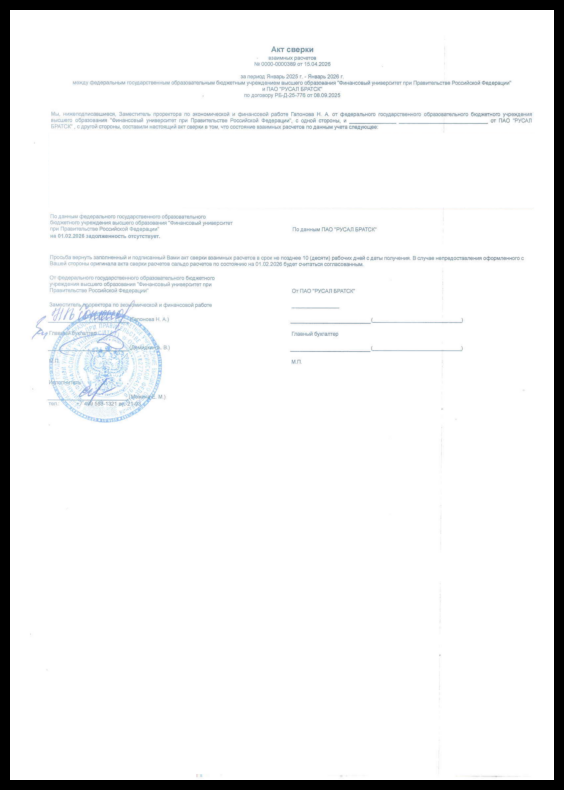

In [18]:
import matplotlib.pyplot as plt

preprocessor = builder.paragraph_detector._preprocessor
table_bboxes = [t.bbox for t in tables]
masked = preprocessor._mask_tables(img, table_bboxes)

plt.figure(figsize=(10, 10))
plt.imshow(masked)
plt.axis("off")
plt.show()

бинаризация изображения перед морфологическими операциями

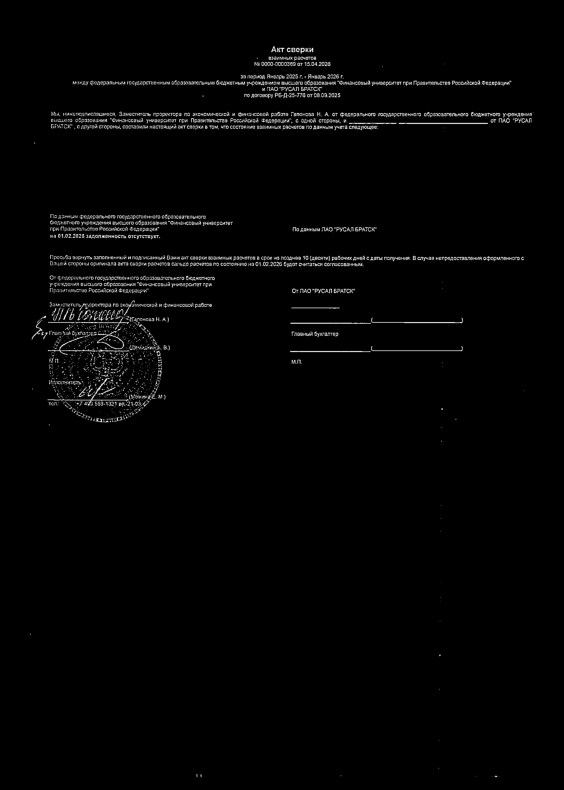

In [19]:
binary = preprocessor._binarize(masked)

plt.figure(figsize=(10, 10))
plt.imshow(binary, cmap='gray')
plt.axis("off")
plt.show()

морфологические опреации для получения грубых форм абзацев

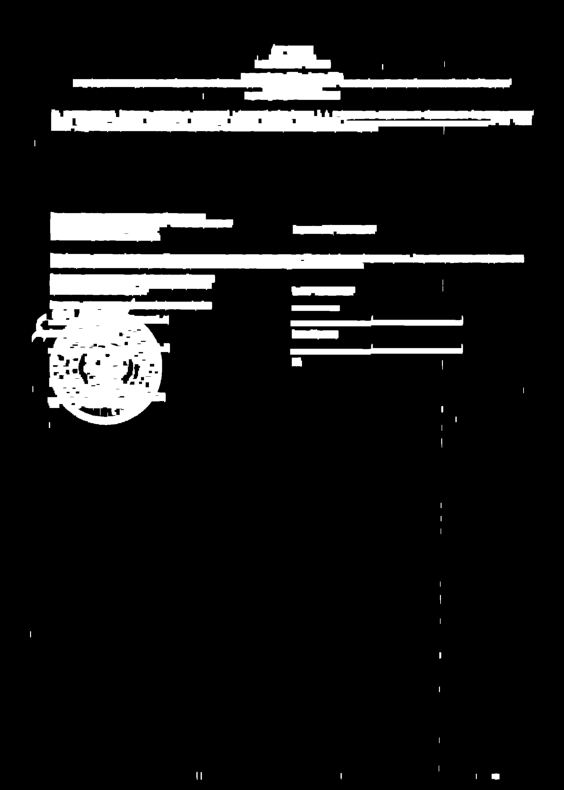

In [20]:
morphed = preprocessor._morphology(binary, median_row_height)

plt.figure(figsize=(10, 10))
plt.imshow(morphed, cmap='gray')
plt.axis("off")
plt.show()

найдем регионы

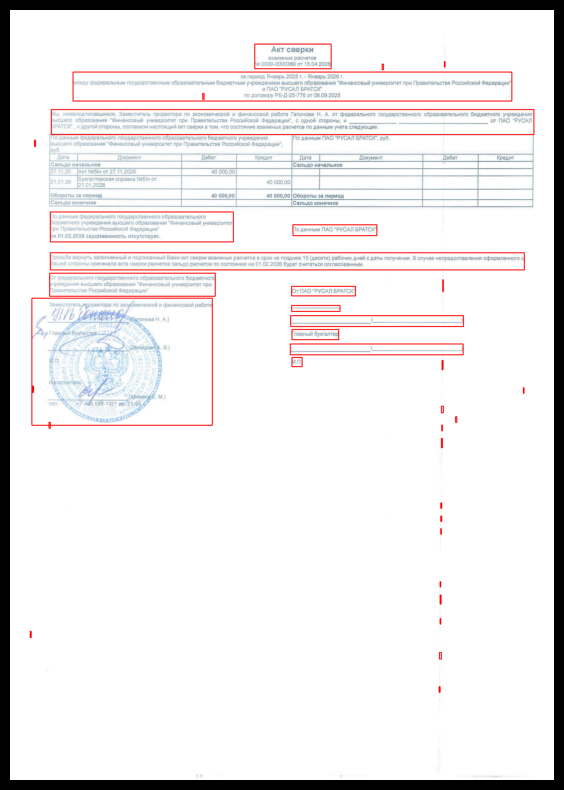

In [21]:
import cv2

regions = preprocessor._find_regions(morphed, page_height=img.shape[0])
reg_image = img.copy()
for roi in regions:
    x, y, w, h = roi.to_tuple()
    cv2.rectangle(reg_image, (x, y), (w, h), (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(reg_image)
plt.axis("off")
plt.show()

In [38]:
paragraphs_mapper = detector._map_ocr_to_regions(filtered_ocr, regions, median_row_height * 0.5)

for p in paragraphs_mapper:
    print(f'[{p.id}] - {p.text}')

2026-06-17 12:30:52.169 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:115 - region[0] строк=3
2026-06-17 12:30:52.170 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:117 -  x=788 y=106  'Акт сверки'
2026-06-17 12:30:52.171 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:117 -  x=781 y=136  'взаимных расчетов'
2026-06-17 12:30:52.171 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:117 -  x=739 y=153  '№º 0000-0000389 OT 15.04.2026'
2026-06-17 12:30:52.173 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:115 - region[1] строк=4
2026-06-17 12:30:52.173 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:117 -  x=695 y=190  'за периодЯнварь 2025 г. - Январь 2026 г.'
2026-06-17 12:30:52.174 | DEBUG    | vision_core.detector.paragraph_detector:_map_ocr_to_regions:117 -  x=186 y=209  'можду федеральным государственным образовательным бюджетным учре

[0] - Акт сверки взаимных расчетов №º 0000-0000389 OT 15.04.2026
[1] - за периодЯнварь 2025 г. - Январь 2026 г. можду федеральным государственным образовательным бюджетным учреждением высшего образования "Финансовый университет при Правительстве Российской Федерации" и ПАО "РУСАЛ БРАТСК" по договору РБ-Д-25-776 от 08.09.2025
[2] - Мы, нижеподписавшиеся, Заместитель проректора по экономической и финансовой работе Гапонова Н. А. от федерального государственного образовательного бюджетного учреждения высшего образования "Финансовый университет при Правительстве Российской Федерации", с одной стороны, и ОТ ПАО "РУСАЛ Братск", с другой стороны, составили настоящий акт сверки в том, что состояние взаимных расчетов по данным учета следующее:
[3] - По данным федерального государственного бюджетного учреждения высшего образования"Финансовый университет при Правительстве Российской Федерации" на 01.02.2026 задолженность отсутствует.
[4] - По ДАННЫМ ПАО "РУСАЛ БРАТСК"
[5] - Просьба вернуть заполн

In [39]:
page_shape = (img.shape[0], img.shape[1])

paragraphs = [p.classify_by_position(page_shape, table_bboxes, median_row_height * 0.5) for p in paragraphs_mapper]



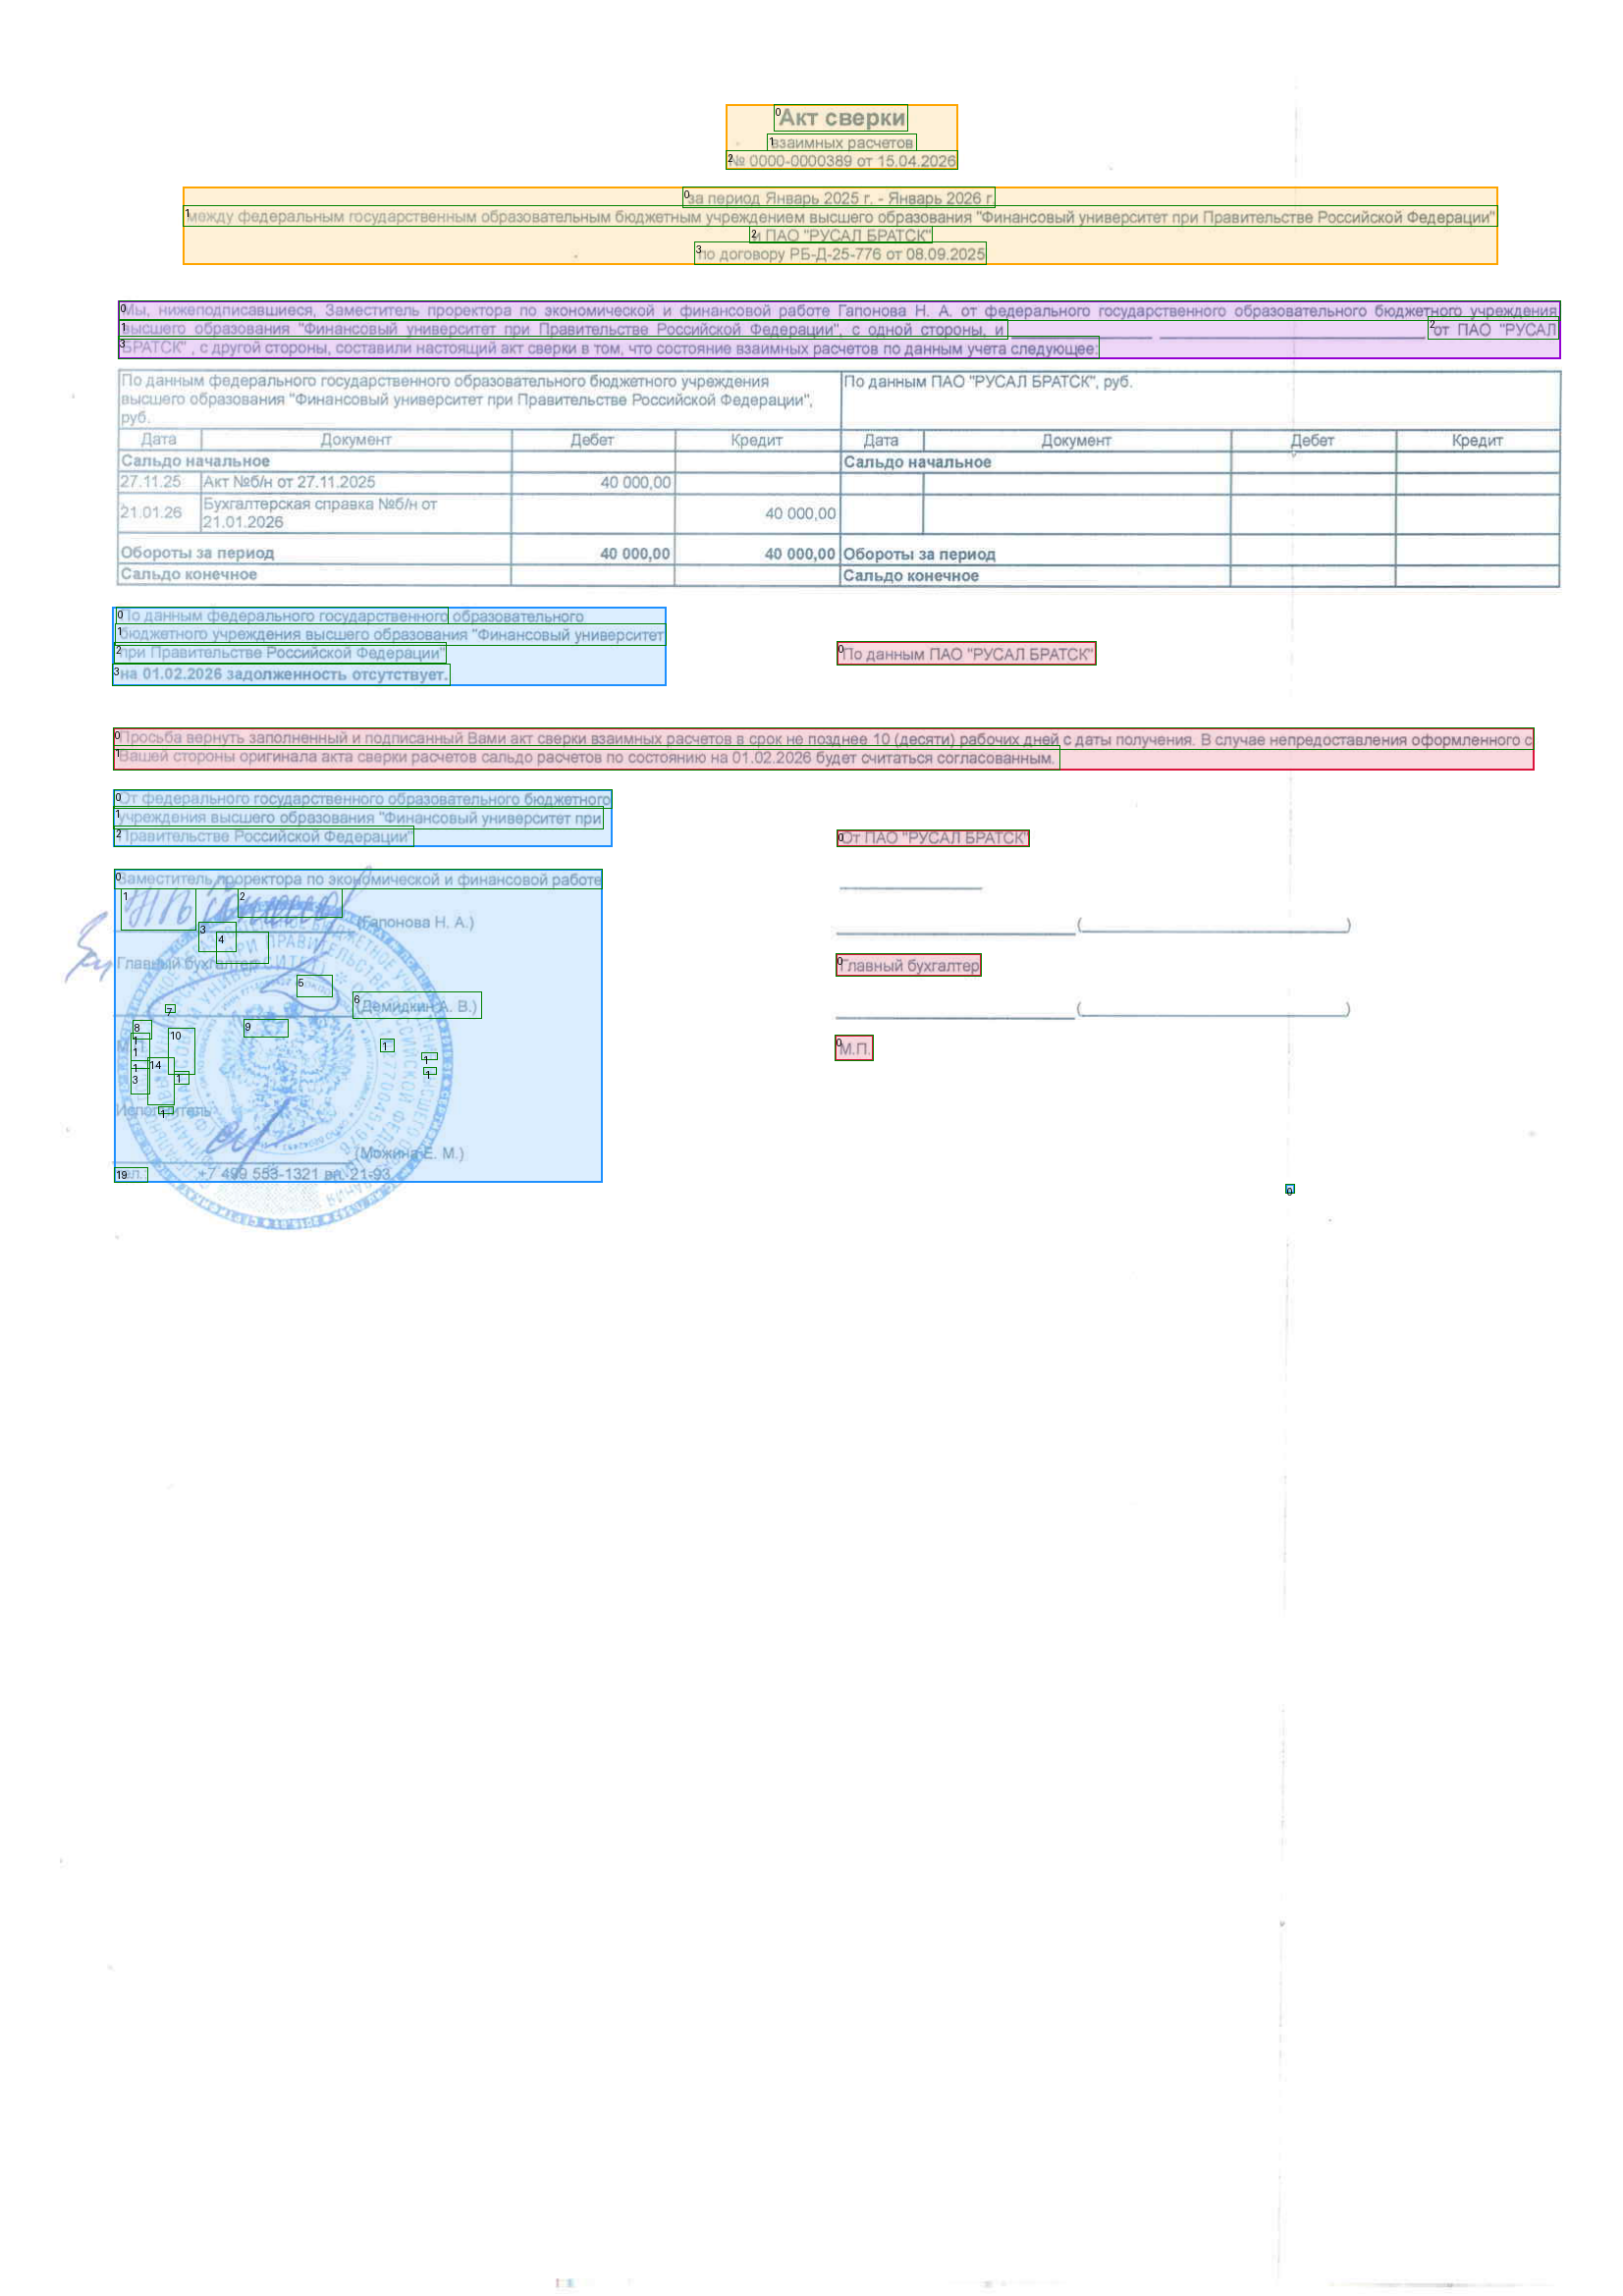

In [40]:
from vision_core.entities.paragraph import ParagraphType
from vision_core.utils.drawer import Drawer

TYPE_COLORS = {
    ParagraphType.PAGE_HEADER:   (255, 165,   0),  # orange
    ParagraphType.PAGE_FOOTER:   (255, 165,   0),  # orange
    ParagraphType.SECTION_TITLE: (220,  20,  60),  # crimson
    ParagraphType.TABLE_CAPTION: (148,   0, 211),  # purple
    ParagraphType.BODY_TEXT:     ( 30, 144, 255),  # blue
    ParagraphType.UNKNOWN:       (128, 128, 128),  # gray
}
img_debug = img.copy()
drawer = Drawer(img_debug)
for p in paragraphs:
    color = TYPE_COLORS[p.type]
    drawer.draw_structure(p.bbox.to_tuple(), color=color, width=2, fill=(*color, 40))
    # drawer.draw_text_in_bbox(p.bbox.to_tuple(), text=p.type.name)
    for idx, b in enumerate(p.blobs):
        drawer.draw_structure(b.to_tuple(), color='green', width=1)
        drawer.draw_text_in_bbox(b.to_tuple(), text=str(idx))

display(drawer.to_pil())